## Task 1: Value Iteration for FrozenLake

MDP definition:
- The state space, S, contains 16 discrete locations on a 4x4 grid represented by integers 0 to 15.
- The action space, A, has 4 possible movements from any given state. The actions are defined as 0: left, 1: down, 2: right, 3: up
- The rewards are as follows:
  - +1 for reaching the goal state (G or state 15)
  - 0 for moving to a frozen state (F)
  - 0 for falling into a hole (H)
- Transitionprobability:
  - Because we set is_slippery to false, the probability of moving to the intended next state is 100%. This would not be the case if we had set is_slippery to True

1. Environment Setup and MDP Definition

In [1]:
import gym
import numpy as np

# Create the FrozenLake environment
env = gym.make('FrozenLake-v1', is_slippery=False)

# Define MDP parameters
# Number of states (16 for 4x4 grid)
num_states = env.observation_space.n
# Number of actions (4: Left, Down, Right, Up)
num_actions = env.action_space.n
discount_factor = 0.9

print(f"Number of states: {num_states}")
print(f"Number of actions: {num_actions}")


Number of states: 16
Number of actions: 4


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-pack

2. Value iteration implementation
- We want to find $V^*(s)$
- WE have: $V(s) = \max_a \sum_{s'} P(s' \mid s,a) \left[ R(s,a,s') + \gamma V(s') \right]$

In [2]:
def value_iteration(env, discount_factor=0.9, theta=1e-8):
    num_states = env.observation_space.n
    num_actions = env.action_space.n
    V = np.zeros(num_states) # Initialize value function to zeros

    while True:
        delta = 0
        # Iterate over all states
        for s in range(num_states):
            v = V[s]
            # Calculate action-values (Q-values) for each action
            q_values = np.zeros(num_actions)
            for a in range(num_actions):
                for prob, next_state, reward, done in env.P[s][a]:
                    q_values[a] += prob * (reward + discount_factor * V[next_state])

            # Update the value function for the current state (take the max Q-value)
            V[s] = np.max(q_values)
            delta = max(delta, abs(v - V[s]))

        # Check for convergence
        if delta < theta:
            break

    # Derive the optimal policy from the optimal value function
    policy = np.zeros(num_states, dtype=int)
    for s in range(num_states):
        q_values = np.zeros(num_actions)
        for a in range(num_actions):
            for prob, next_state, reward, done in env.P[s][a]:
                q_values[a] += prob * (reward + discount_factor * V[next_state])
        policy[s] = np.argmax(q_values)

    return V, policy

V, policy = value_iteration(env, discount_factor)


3. Original Grid/visualization

The FrozenLake 4x4 grid can be visualized as:
```
S F F F
F H F H
F F F H
H F F G
```
Where:
- S: Starting point
- F: Frozen surface
- H: Hole (death)
- G: Goal (reward)

In [3]:
print("Optimal Value Function (V):")
print(V.reshape(4,4))
print("\n")

print("Optimal Policy (P):")
# Map action integers to symbols for better readability
action_symbols = {0: '←', 1: '↓', 2: '→', 3: '↑'}
policy_symbols = np.array([action_symbols[a] for a in policy])
print(policy_symbols.reshape(4,4))


Optimal Value Function (V):
[[0.59049 0.6561  0.729   0.6561 ]
 [0.6561  0.      0.81    0.     ]
 [0.729   0.81    0.9     0.     ]
 [0.      0.9     1.      0.     ]]


Optimal Policy (P):
[['↓' '→' '↓' '←']
 ['↓' '←' '↓' '←']
 ['→' '↓' '↓' '←']
 ['←' '→' '→' '←']]


4. Varying the discount factor
- If discount is high future rewards are valued like immediate rewards. Will take longer path if lead to larger cumulative reward
- If discount factor is lowp, immediate rewards are more important than future rewards. Prioritizes reaching rewards quickly even if smaller & avoids riskier paths that delay the rewards

In [4]:
# Experiment with a lower discount factor
low_discount_factor = 0.1
V_low_gamma, policy_low_gamma = value_iteration(env, low_discount_factor)

print(f"\nOptimal Policy with gamma = {discount_factor}:")
policy_symbols_orig = np.array([action_symbols[a] for a in policy])
print(policy_symbols_orig.reshape(4,4))

print(f"\nOptimal Policy with gamma = {low_discount_factor}:")
policy_symbols_low = np.array([action_symbols[a] for a in policy_low_gamma])
print(policy_symbols_low.reshape(4,4))

# Experiment with a higher discount factor
high_discount_factor = 0.99
V_high_gamma, policy_high_gamma = value_iteration(env, high_discount_factor)

print(f"\nOptimal Policy with gamma = {high_discount_factor}:")
policy_symbols_high = np.array([action_symbols[a] for a in policy_high_gamma])
print(policy_symbols_high.reshape(4,4))



Optimal Policy with gamma = 0.9:
[['↓' '→' '↓' '←']
 ['↓' '←' '↓' '←']
 ['→' '↓' '↓' '←']
 ['←' '→' '→' '←']]

Optimal Policy with gamma = 0.1:
[['↓' '→' '↓' '←']
 ['↓' '←' '↓' '←']
 ['→' '↓' '↓' '←']
 ['←' '→' '→' '←']]

Optimal Policy with gamma = 0.99:
[['↓' '→' '↓' '←']
 ['↓' '←' '↓' '←']
 ['→' '↓' '↓' '←']
 ['←' '→' '→' '←']]


How policy changes with changes to discount rate (gamma):

In this scenario, the policy does not change at all. This is because of the frozen lake v1 environment. In this environment, the only rewards are 1 for the goal and 0 for everything else. Since there are no penalties and only one reward, the optimal policy does not change regardless of the discount rate. This can also be said because there is 100% probability of going to the intended next state.

If we had is_slippery=True, lower gamma values might have lead to more conservative policies that avoid riskier paths even if they were shorter because the penalty for falling into a hole is imediate termination.



5. Why FrozenLake is an MDP and what the policy is doing

FrozenLake is an MDP because it satisfies the Markov Property. It has States, Actions, Transition Probabilities (in this case 100%), rewards, and a discount factor. Since future state and rewards only rely on the current state and action, the Markov Property holds and allows this environment to be solved with MDP solution methods like value iteration.

The learned policy tells the agent what the optimal action to take in each state is. It does this to maximize the expected cumulative discounted reward. The goal in this scenario is to reach 'G' or state 15 and get the +1. It learns to avoid the 'H' tiles as hitting those holes would cause termination. The arrows depicted in the policy indicate the agent should move from each tile to eventually reach the goal while minimizing the risk of falling into a hole and maximizing the discounted sum of rewards. States like the hole or goal will show arbitrary actions, however, the value function will reflect the termination and reward for those states.

# Task 2: Mini Research Task on Diffusion Models

1. Primary Source (diffusion models foundational paper)

Ho, J., Jain, A., & Abbeel, P. (2020). Denoising Diffusion Probabilistic Models. arXiv preprint arXiv:2006.11239.(Direct PDF: https://arxiv.org/pdf/2006.11239)

2. Secondary Source (paper introducing latent diffusion models (foundation for stable diffusion))

Rombach, R., Blattmann, A., Lorenz, D., Esser, P., & Ommer, B. (2022). High-Resolution Image Synthesis with Latent Diffusion Models. arXiv preprint arXiv:2112.10752.(Direct PDF: https://arxiv.org/pdf/2112.10752)


### Problem Solved:

Traditional generative models like GANs often have training instability, mode collapse, or poor sample diversities and autoregressive model are slow with higher resolutions. Diffusion models aim to solve the challenge of having high-quality and stable generation of complex data like images by modeling generation as a reversible denoising process. These provide a likelihood based framework to produce diverse samples without using adversarial training.

Diffusion models work by starting with real data and gradually destroying them with small amounts of noise over multiple timesteps. This is repeated until the data becomes pure random noise. A neural network is then trained to reverse this process by taking noisy data at any time step and undoing the noise at that step. The noise is removed step by step this way tp recover a clean sample. Since the process of adding noise (forward diffusion) is easy to simulate, the model only needs to learn the denoising.

The architecture and training has two processes:

The forward process is fixed and involves no training. It involves a markkov chain that adds more gaussian noise over time. It works such that if you had an $x_0$, then as we add more noise $x_0 \to x_1 \to x_2 \to ... \to x_T$ then at the end $x_T \approx N(0, 1)$.

The reverse process on the other hand is learned. This process tries to start at noise $x_T$ and iteratively denoise in order to get the sample $x_0$. This reverse process wants to invert $p_\theta(x_{t-1}|x_t)$.

The architecture to do this is to use a U-net backbone. A U-Net is an encoder (typically using a standaard convolutional neural network) and then a decoder alongside skip connections in order to pass finer spatial details forward straight from the encoder to the decoder.

This is then typically used to predict noise $ϵ_\theta(x_t, t)$




#### Small experiment/demo of a stable diffusion model with different numbers of denoising steps:

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/10 [00:00<?, ?it/s]

Generated with 10 steps in 0.2 seconds


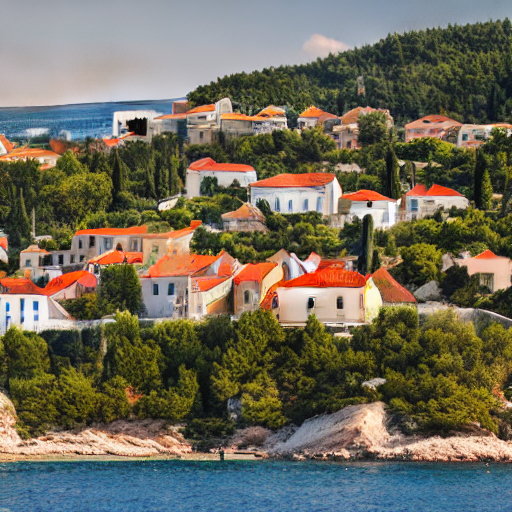

  0%|          | 0/40 [00:00<?, ?it/s]

Generated with 40 steps in 0.8 seconds


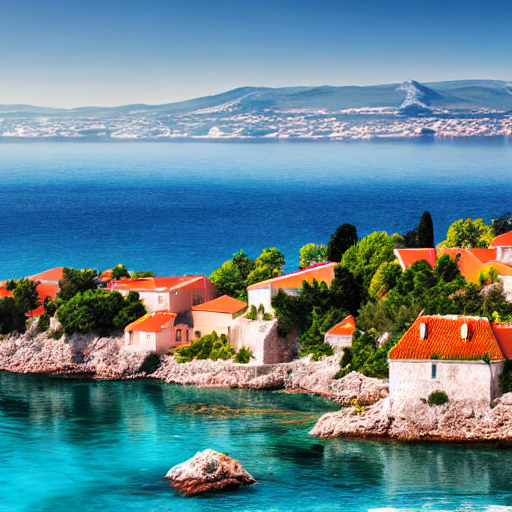

  0%|          | 0/70 [00:00<?, ?it/s]

Generated with 70 steps in 1.3 seconds


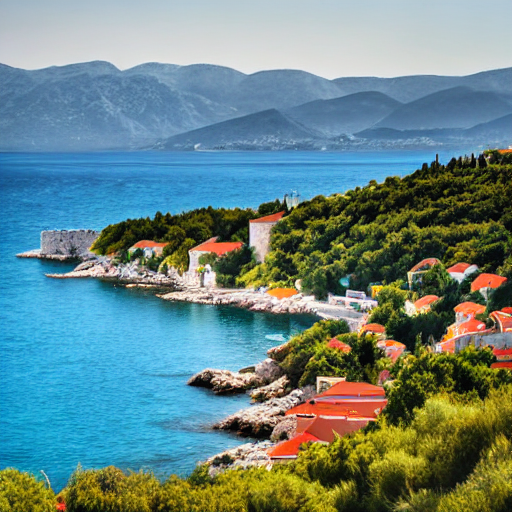

  0%|          | 0/100 [00:00<?, ?it/s]

Generated with 100 steps in 1.8 seconds


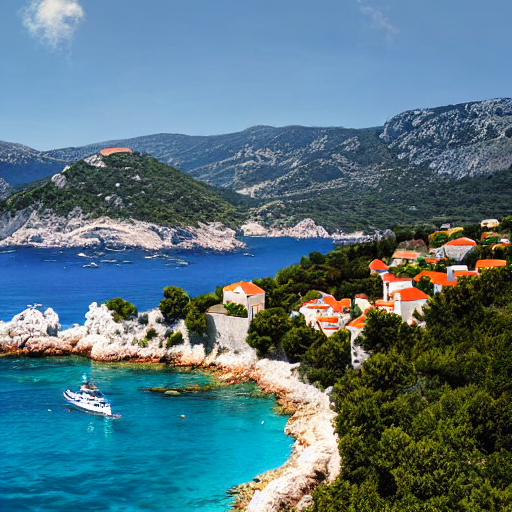

In [13]:
import torch
from diffusers import DiffusionPipeline
import time
from IPython.display import display

# Load a pretrained Stable Diffusion v1.5 model
pipe = DiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
    torch_dtype=torch.float16,
    use_safetensors=True
)
pipe = pipe.to("cuda" if torch.cuda.is_available() else "cpu")

prompt = "A realistic image of the coast of croatia with coastal houses and the mountains"
generator = torch.Generator(device=pipe.device).manual_seed(42)

# compare different numbers of denoising steps
for num_steps in range(10, 101, 30):
    start = time.time()
    image = pipe(
        prompt,
        num_inference_steps=num_steps,
        guidance_scale=7.5,
        generator=generator
    ).images[0]
    end = time.time()

    print(f"Generated with {num_steps} steps in {end-start:.1f} seconds")
    display(image)


We can see that as the number of denoising steps increase, the images get better over time. The starting houses are extremely blurry, and smudged. The water enters the skyline and the water colors and texture are completely different. As the number of iterations goes up, the water in separate parts of the image become more alike while the houses become less smudged and blurry. The overall quality of the images increases a lot as the number of denoising steps increase.

#### Limitations and risks

1. Computationally, the inference for diffusion models requires many sequential steps. Even if you give a low number of steps like 20-50, it is slower than a single GAN forward pass. This brings real challenges with real-time uses where it needs to generate in a fast time. Additionally, because of its structure, the compute cost for training these models is very high and often requires long training times, large datasets, and strong GPU/TPU's.

2. The biggest risk with image generative models and specifically diffusion models is the generation of deepfakes, copyrighted content, and biased or harmful content that is picked up from the training data. This risk is not inherently associated with diffusion models as it applies to most generative models as they can generate harmful content without the correct measures in place. Even with the correct measures it may be impossible to enforce behavior that does not pose some risk.

#### Extension to the experiment

My next experiment would likely involve comparing schedulers. With speed being a major issue in diffusion models, I would like to investigate how scheduler choice affects the quality to speed tradeoff. To do this you would keep the number of denoising steps fixed at a certain number and then run a certain number of generations per scheduler on a set of prompts. To compare you could then use something like a CLIP score to quantitativelty measure the image's alignment with the text prompt. Though this will not directly measure the sharpness of the image which is more of a perceptual scoring that would need to be done by a human.